**1. Importing the Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importing the Data**

In [ ]:
path="/content/drive/MyDrive/Data quuuality/2015.csv"
df=pd.read_csv(path)
df.head(159)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302


**3. Data Dimensions**

In [ ]:
df.shape

(158, 12)

4. Data Characteristics

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

**5. Statistical Characteristics of Data**

In [ ]:
df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


**6. Handling missing values in dataset**

In [ ]:
df.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

**7. Handling the duplicate values**

In [ ]:
df.drop_duplicates(inplace=True)

remaining_duplicates = df[df.duplicated()]
print(len(remaining_duplicates))
print(df.head())

0
       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553                   1.32629  1.32261   

   Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
0                   0.94143  0.66557                        0.41978   
1                   0.94784  0.62877                        0.14145   
2                   0.87464  0.64938         

**8. Handling the outliers**

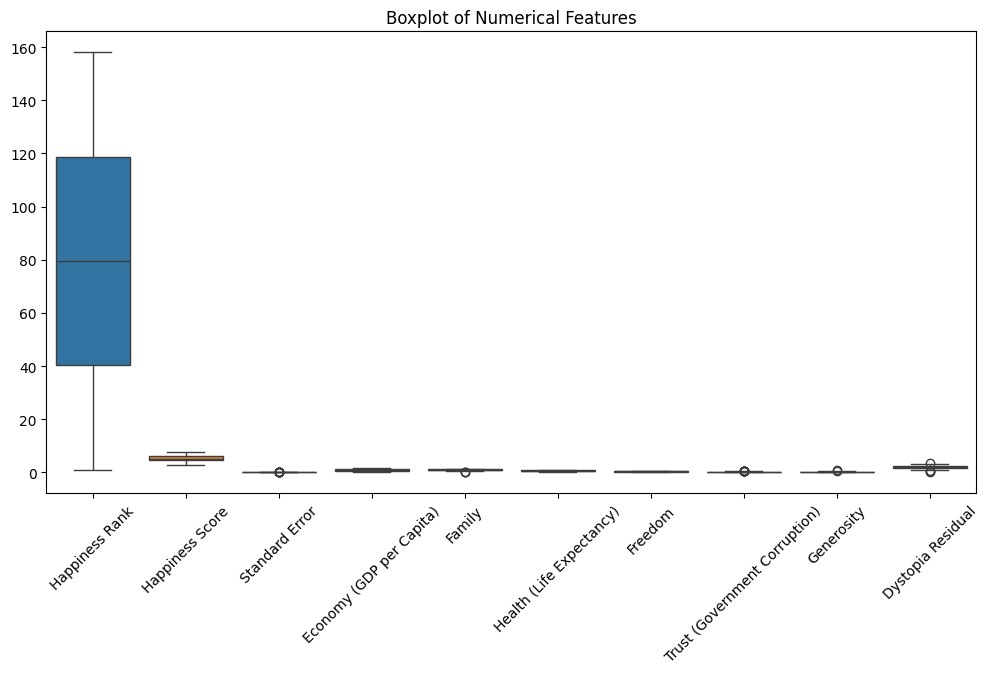

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

**9. a) Drop outlier Values or replace**

In [ ]:
numeric_data = df.select_dtypes(include=['number'])

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = ((numeric_data < lower_bound) | (numeric_data > upper_bound)).any(axis=1)


df.loc[outliers, numeric_data.columns] = df[numeric_data.columns].median()

**9. b) Plot the boxplot and check the Outliers**

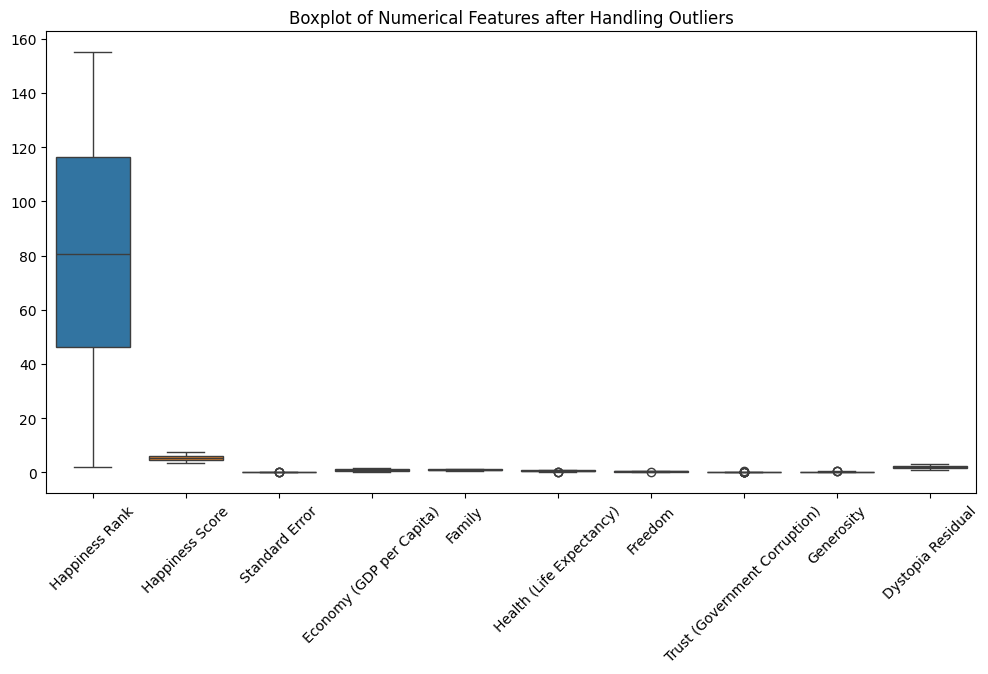

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Boxplot of Numerical Features after Handling Outliers")
plt.xticks(rotation=45)
plt.show()

**10. Normalizing and Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

happiness_score = df['Happiness Score'].values.reshape(-1, 1)
scaler.fit(happiness_score)

normalized_happiness_score = scaler.transform(happiness_score)

df['Happiness Score'] = normalized_happiness_score

print("First few rows after normalization:")
print(df.head())

First few rows after normalization:
       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe             NaN              NaN   
1      Iceland  Western Europe             2.0         2.170187   
2      Denmark  Western Europe             NaN              NaN   
3       Norway  Western Europe             NaN              NaN   
4       Canada   North America             5.0         2.039025   

   Standard Error  Economy (GDP per Capita)   Family  \
0             NaN                       NaN      NaN   
1         0.04884                   1.30232  1.40223   
2             NaN                       NaN      NaN   
3             NaN                       NaN      NaN   
4         0.03553                   1.32629  1.32261   

   Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
0                       NaN      NaN                            NaN   
1                   0.94784  0.62877                        0.14145   
2          

**11.a)  Finding the Pairwise Correlation between the different
Data**

In [ ]:
print(df.dtypes)

correlation_columns = ['Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

for col in correlation_columns:
    non_numeric_values = df[col].apply(lambda x: not isinstance(x, (int, float)))
    if non_numeric_values.any():
        print(f"Non-numeric values found in column: {col}")

df[correlation_columns] = df[correlation_columns].replace('[^0-9.-]', np.nan, regex=True)

correlation_matrix = df[correlation_columns].corr()
print("Correlation matrix:")
print(correlation_matrix)

Country                           object
Region                            object
Happiness Rank                   float64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object
Correlation matrix:
                               Happiness Score  Economy (GDP per Capita)  \
Happiness Score                       1.000000                  0.752534   
Economy (GDP per Capita)              0.752534                  1.000000   
Family                                0.696713                  0.615629   
Health (Life Expectancy)              0.736381                  0.795092   
Freedom                               0.496880                  0.247511   
Trust (Government 

**11.b) Create  Heatmap using Seaborn to Visualize the Correlation between different Data**

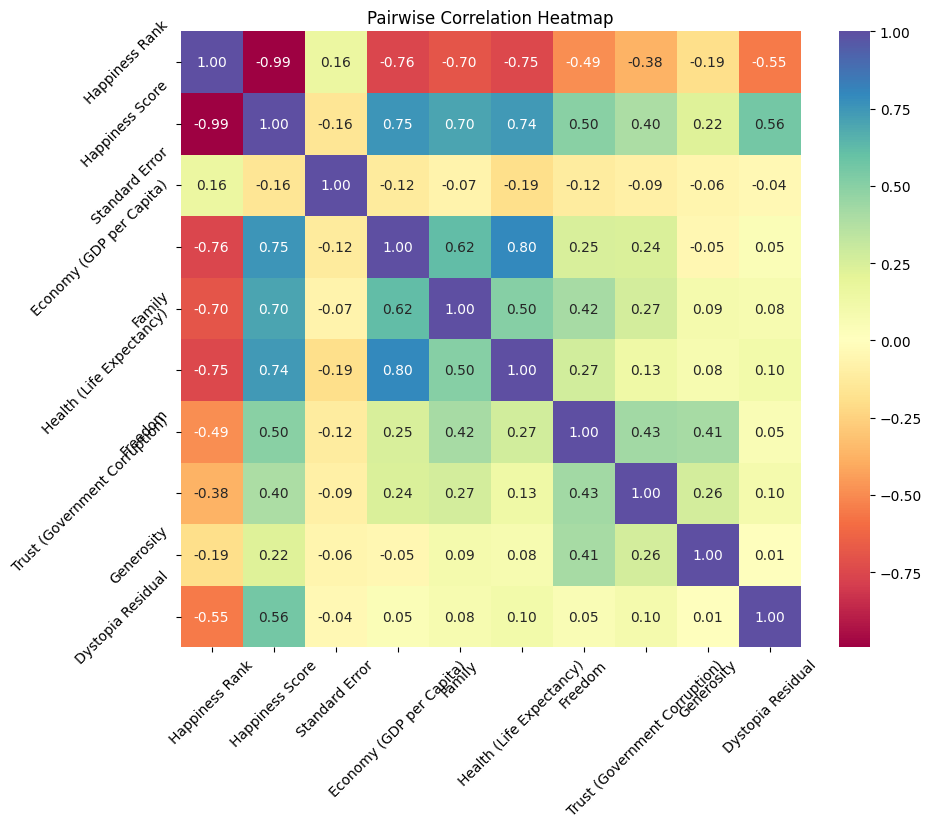

In [ ]:
numeric_data = df.select_dtypes(include=['number'])


correlation_matrix = numeric_data.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="Spectral", fmt=".2f", annot_kws={"size": 10})
plt.title("Pairwise Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

**11.c) Observations from the above Heatmap of Correlations**

Correlation matrix for highly correlated columns:
                          Happiness Score  Economy (GDP per Capita)    Family  \
Happiness Score                  1.000000                  0.752534  0.696713   
Economy (GDP per Capita)         0.752534                  1.000000  0.615629   
Family                           0.696713                  0.615629  1.000000   
Health (Life Expectancy)         0.736381                  0.795092  0.503143   

                          Health (Life Expectancy)  
Happiness Score                           0.736381  
Economy (GDP per Capita)                  0.795092  
Family                                    0.503143  
Health (Life Expectancy)                  1.000000  


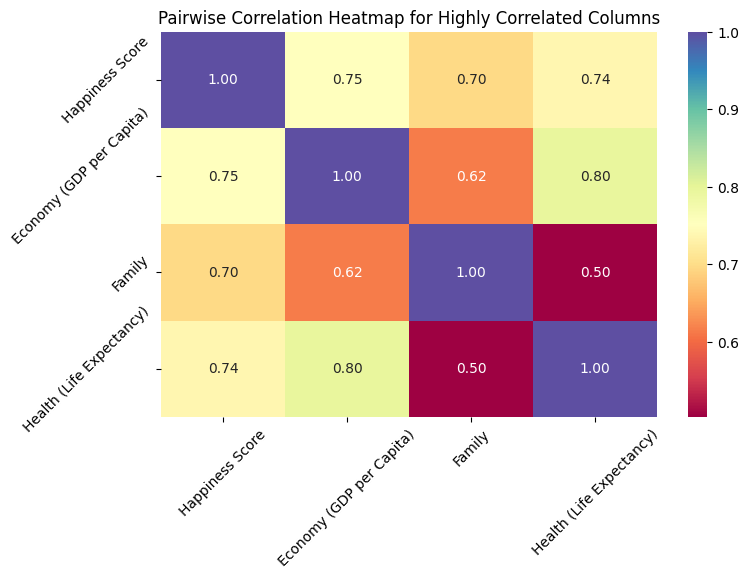

In [ ]:
correlation_subset = df[['Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)']]

correlation_matrix = correlation_subset.corr()

print("Correlation matrix for highly correlated columns:")
print(correlation_matrix)

plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="Spectral", fmt=".2f", annot_kws={"size": 10})
plt.title("Pairwise Correlation Heatmap for Highly Correlated Columns")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

**12.a) Visualizing relation between Economy (GDP per
Capita) and Happiness Score using  Regression plot.**

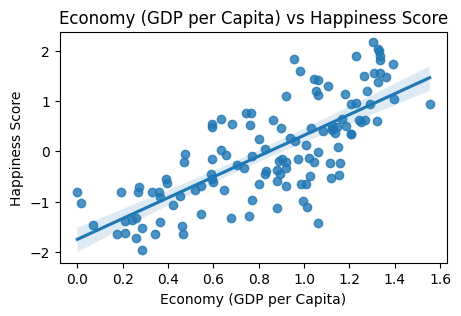

In [ ]:
plt.figure(figsize=(5, 3))
sns.regplot(x='Economy (GDP per Capita)', y='Happiness Score', data=df)
plt.title('Economy (GDP per Capita) vs Happiness Score')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.show()

**12.b) Visualizing relation between Family and Happiness Score using Regression Plot**

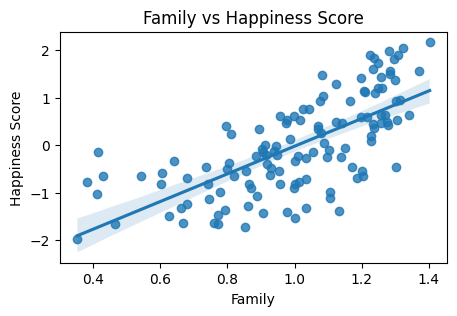

In [ ]:
plt.figure(figsize=(5, 3))
sns.regplot(x='Family', y='Happiness Score', data=df)
plt.title('Family vs Happiness Score')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.show()

**12.c) Visualizing relation between Health (Life Expectancy) and Happiness
Score using Regression Plot**

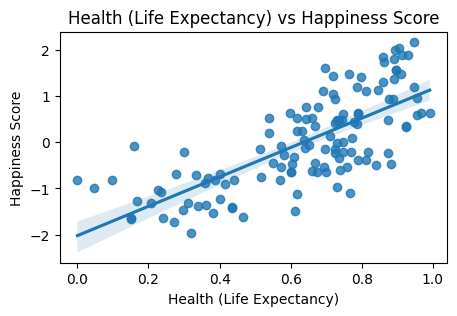

In [ ]:
plt.figure(figsize=(5, 3))
sns.regplot(x='Health (Life Expectancy)', y='Happiness Score', data=df)
plt.title('Health (Life Expectancy) vs Happiness Score')
plt.xlabel('Health (Life Expectancy)')
plt.ylabel('Happiness Score')
plt.show()

**12.d) Visualizing relation between Freedom and Happiness Score using Regression Plot**

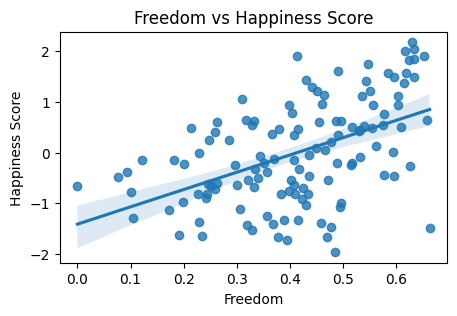

In [ ]:
plt.figure(figsize=(5, 3))
sns.regplot(x='Freedom', y='Happiness Score', data=df)
plt.title('Freedom vs Happiness Score')
plt.xlabel('Freedom')
plt.ylabel('Happiness Score')
plt.show()